In [1]:
import requests, re
from pyquery import PyQuery as pq
import pandas as pd
import time as tm
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pycountry
import wbgapi as wb

In [6]:
pycountry.countries.get(name='Japan')

Country(alpha_2='JP', alpha_3='JPN', flag='🇯🇵', name='Japan', numeric='392')

In [111]:
series = 'FM'
period = 'A' # Q, M, A for quarterly, monthly or annually statistics
country = 'JPN' # two letter country code
time_start = 2000
time_end = 2025

In [7]:
search_term = 'spending'

In [9]:
key = f'DataStructure/{series}'
url = 'http://dataservices.imf.org/REST/SDMX_JSON.svc/'

dimension_list = requests.get(f'{url}{key}').json()['Structure']['KeyFamilies']['KeyFamily']['Components']['Dimension']

key = f"CodeList/{dimension_list[2]['@codelist']}"

code_list = requests.get(f'{url}{key}').json()['Structure']['CodeLists']['CodeList']['Code']

for code in code_list:
    if (search_term in code['Description']['#text'].lower()):
        print(f"{code['Description']['#text']}: {code['@value']}")

In [107]:
def _download_imf_ts(series=series, period=period, country=country, code=code, time_start=time_start, time_end=time_end):
   
   # building the url to access the RESTful API
    base = f'http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/{series}/'
    time = f'?startPeriod={time_start}&endPeriod={time_end}'
    url = f'{base}{period}.{country}.{code}.{time}'
    #print(url)
    rq = requests.get(url)
    if rq.status_code == 200:
        try:
            response = rq.json()
            #print(response)
            series = response['CompactData']['DataSet']['Series']
            #print(series)
            temp_dic = series.get('Obs')
            #print(temp_dic)
            df = pd.DataFrame.from_dict(temp_dic).rename( 
                    columns = {
                        '@OBS_VALUE' : 'Value',
                        '@OBS_STATUS': 'Status'
                    }
            )
            df['Country'] = series.get('@REF_AREA')
            df['Indicator'] = series.get('@INDICATOR')

            df['Period'] = pd.to_datetime([row.replace('-', '') for row in df['@TIME_PERIOD']])
            df.drop('@TIME_PERIOD', axis=1, inplace=True)

            df["Value"] = df["Value"].astype("double")
            df = df[['Period', 'Value']]
            df = df.set_index('Period')

        except:
            print(f"Error for {country} {code}: {url}")
            df = pd.DataFrame()
    return df

In [109]:
real_GDP= _download_imf_ts(code="G2M_S13_POGDP_PT")

Error for US G2M_S13_POGDP_PT: http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/FM/A.US.G2M_S13_POGDP_PT.?startPeriod=2000&endPeriod=2025


In [97]:
real_GDP= _download_imf_ts(code="G1_S13_POGDP_PT")

Error for JPN G1_S13_POGDP_PT: http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/FM/A.JPN.G1_S13_POGDP_PT.?startPeriod=2000&endPeriod=2025


In [186]:
checkableDeps= _download_imf_ts(code='56DG__XDC')

Error for JP 56DG__XDC: http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/IFS/A.JP.56DG__XDC.?startPeriod=2000&endPeriod=2023


In [73]:
interestRates = _download_imf_ts(code='FPOLM_PA')

Error for JPN FPOLM_PA: http://dataservices.imf.org/REST/SDMX_JSON.svc/CompactData/FM/A.JPN.FPOLM_PA.?startPeriod=2000&endPeriod=2025


<Axes: xlabel='Period'>

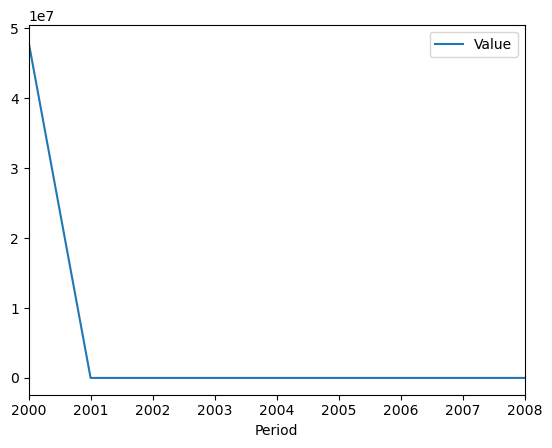

In [184]:
a = checkableDeps
a.plot()

<Axes: xlabel='Period'>

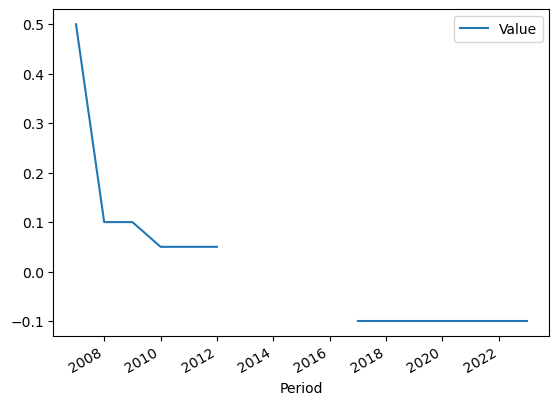

In [124]:
interestRates.plot()

In [16]:
consumption_C = _download_imf_ts(code='NC_R_XDC') #Final Consumption Expenditure, Real, Domestic Currency

<Axes: xlabel='Period'>

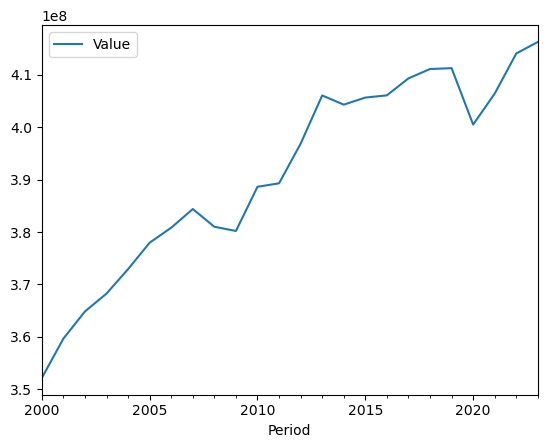

In [45]:
consumption_C.plot()

In [19]:
investment_I = _download_imf_ts(code='NFI_R_XDC') #Gross Fixed Capital Formation (GFCF) in real domestic currency

In [20]:
govSpending_G = _download_imf_ts(code='NCGG_R_XDC') #General Government Final Consumption Expenditure in real domestic currency

In [21]:
exports_X = _download_imf_ts(code='NX_R_XDC') #Exports of Goods and Services, Real, Domestic Currency

In [22]:
imports_IM = _download_imf_ts(code='NM_R_XDC') #Imports of Goods and Services, Real, Domestic Currency 

In [23]:
disposableIncome_Y=(wb.data.DataFrame('NY.GDS.TOTL.CN','JPN', range(2000,2024)).transpose())/1000000  #Household's Gross Disposable Income in domestic currency.
disposableIncome_Y = disposableIncome_Y.rename(columns={'JPN': 'Value'}) #Adjusting wbgapi to requests format

In [29]:
cons_C=(wb.data.DataFrame('NE.CON.PRVT.CN','JPN', range(2000,2024)).transpose())/1000000

In [31]:
cons_C

economy,JPN
YR2000,287352100.0
YR2001,289337000.0
YR2002,288790900.0
YR2003,287643700.0
YR2004,289742500.0
YR2005,291828900.0
YR2006,294498900.0
YR2007,295716700.0
YR2008,294334600.0
YR2009,285154400.0


In [33]:
import statsmodels.api as sm

In [35]:
cons_C.columns = ['Consumption']
disposableIncome_Y.columns = ['Disposable_Income']

# Merge the two dataframes on their index (which is the year)
data = pd.merge(cons_C, disposableIncome_Y, left_index=True, right_index=True)

# Drop rows with missing values
data.dropna(inplace=True)

# Prepare the data for linear regression: Y = c0 + c1 * X
X = data['Disposable_Income']
X = sm.add_constant(X)  # Adds a constant (c0) to the model
y = data['Consumption']

# Perform linear regression
model = sm.OLS(y, X).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Consumption   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.2109
Date:                Thu, 27 Mar 2025   Prob (F-statistic):              0.651
Time:                        11:17:28   Log-Likelihood:                -394.37
No. Observations:                  23   AIC:                             792.7
Df Residuals:                      21   BIC:                             795.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              2.875e+08   1.47e+0

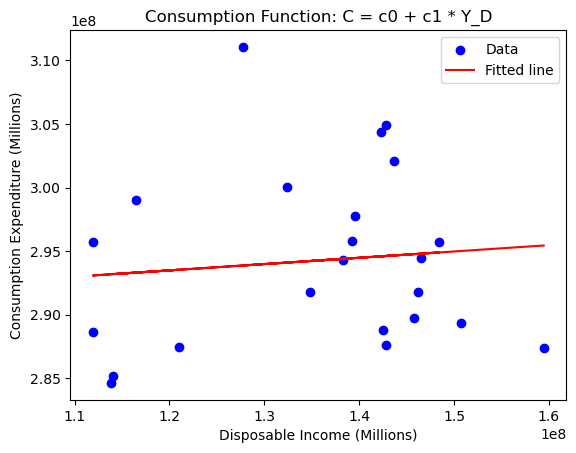

In [37]:
# Plot the original data
plt.scatter(data['Disposable_Income'], data['Consumption'], color='blue', label='Data')

# Plot the regression line
plt.plot(data['Disposable_Income'], model.predict(X), color='red', label='Fitted line')

plt.xlabel('Disposable Income (Millions)')
plt.ylabel('Consumption Expenditure (Millions)')
plt.legend()
plt.title('Consumption Function: C = c0 + c1 * Y_D')
plt.show()


<Axes: >

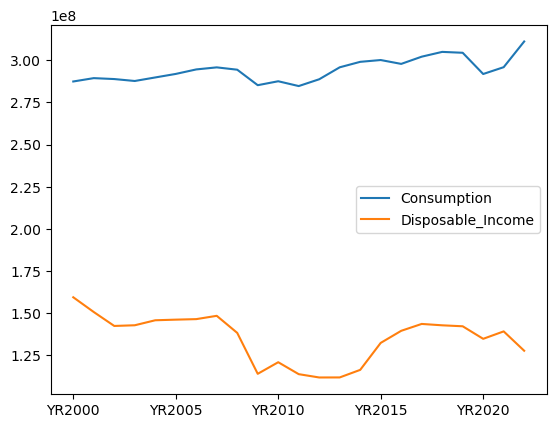

In [39]:
data.plot()

In [39]:
netExports = exports_X-imports_IM 

In [ ]:
# Assuming 'df' is the DataFrame containing 'disposable_income' and 'consumption_expenditure'
X = df['disposable_income']
X = sm.add_constant(X)  # Adds a constant term (c0) to the model
y = df['consumption_expenditure']

model = sm.OLS(y, X).fit()
print(model.summary())

In [374]:
goodsDemand_Z = consumption_C+investment_I+govSpending_G+netExports

<Axes: xlabel='Period'>

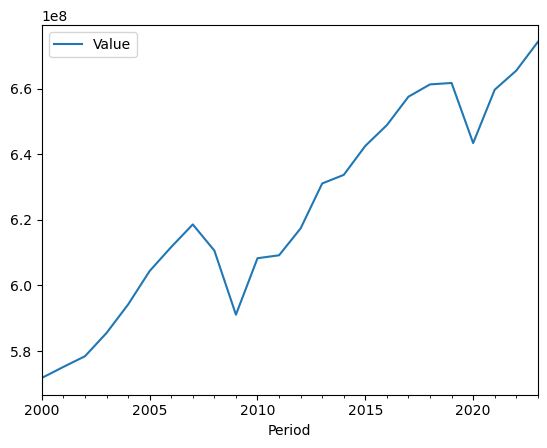

In [378]:
goodsDemand_Z.plot()

<Axes: xlabel='Period'>

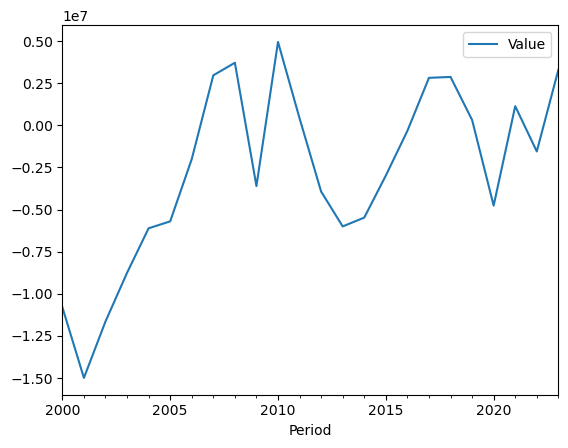

In [340]:
netExports.plot()

In [328]:
investment_I.columns = ['Investment']
govSpending_G.columns = ['Government Spending']
consumption_C.columns = ['Consumption']

In [330]:
combined_data = pd.concat([investment_I, govSpending_G,consumption_C], axis=1)

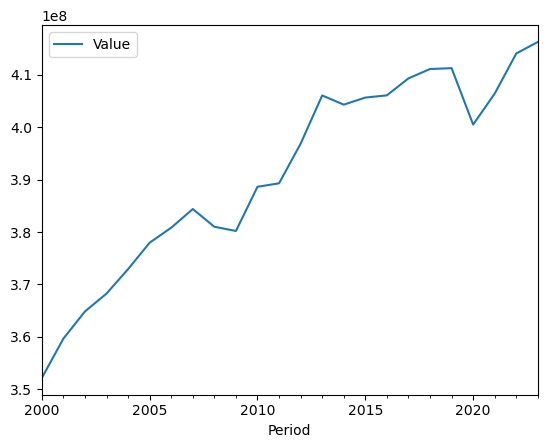

In [228]:
Consumption_C.plot()
plt.show()